<a href="https://colab.research.google.com/github/eswardn12/Data-Science-60-Day-Portfolio/blob/main/Day1_ML_AI_Foundations_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 1 — ML & AI Foundations: Hands-On Notebook
eCommerce/Retail Lens (eBay/Walmart-style)

This notebook operationalizes the concepts from the Day 1 report through three case studies:

1. **(Deep) Listing Quality Classifier** — Logistic Regression vs Random Forest vs XGBoost
2. **(Deep) Regional Demand Regression** — Linear Regression vs Gradient Boosted Trees
3. **(Lighter) Buyer Segmentation** — K-Means with elbow/silhouette selection

Plus a **Named Extensions** section (scoped, not fully built) for further independent practice reps.

All data is **synthetic**, engineered to mimic realistic eBay/Walmart-style distributions and relationships — safe for a public GitHub portfolio.


In [ ]:
# Environment setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
                              classification_report, r2_score, mean_absolute_percentage_error,
                              silhouette_score, average_precision_score)
from sklearn.cluster import KMeans
from xgboost import XGBClassifier

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
EBAY_BLUE = '#0064D2'
EBAY_RED = '#E53238'
EBAY_GOLD = '#F5AF02'
EBAY_GREEN = '#86B817'
print('Environment is ready.')


Environment is ready.


---
## Case Study 1 (Deep) — Listing Quality Classifier
**Business framing:** eBay's Catalog Quality team wants to flag listings likely to be suppressed in search due to low quality (thin titles, missing images, no brand tag, price outliers for the category) *before* a human QA pass — directly extending the eBay churn masterclass's confusion-matrix and precision/recall framework (Day 1 report, Section 5) to a second business problem.

**Label:** `low_quality_flag` = 1 if the listing would be flagged as low quality (~20-25% base rate, mirroring eBay's typical buyer-churn-scale imbalance).


In [ ]:
# 1.1 Synthetic data generation — Listing Quality
n = 6000
df1 = pd.DataFrame({
    'title_length': np.random.randint(10, 120, n),
    'num_images': np.random.poisson(3, n).clip(0, 12),
    'has_brand_tag': np.random.binomial(1, 0.6, n),
    'seller_feedback_score': np.random.normal(97, 5, n).clip(50, 100),
    'price_zscore_in_category': np.random.normal(0, 1, n),
    'description_length': np.random.randint(0, 800, n),
    'category_competitiveness': np.random.uniform(0, 1, n),
})

def z(s):
    return (s - s.mean()) / s.std()

price_abs_z = df1['price_zscore_in_category'].abs()
logit = (
    -0.9 * z(df1['title_length'])
    - 0.7 * z(df1['num_images'])
    - 1.3 * z(df1['has_brand_tag'])
    - 1.1 * z(df1['seller_feedback_score'])
    + 0.9 * z(price_abs_z)
    - 0.5 * z(df1['description_length'])
    + 1.0 * z(df1['category_competitiveness'])
    + 0.9 * z(price_abs_z) * z(df1['category_competitiveness'])   # interaction: trees should exploit this better than linear model
    - 2.2
)
prob = 1 / (1 + np.exp(-logit))
df1['low_quality_flag'] = np.random.binomial(1, prob.clip(0.02, 0.95))

print(f'Shape: {df1.shape}')
print(f'Low-quality flag rate: {df1.low_quality_flag.mean():.2%}')
df1.head()


Shape: (6000, 8)
Low-quality flag rate: 23.53%


,title_length,num_images,has_brand_tag,seller_feedback_score,price_zscore_in_category,description_length,category_competitiveness,low_quality_flag
0,112,2,0,100.000000,0.042484,574,0.047847,0
1,61,2,0,94.564382,-1.738192,695,0.000765,0
2,102,5,1,92.871835,0.245627,212,0.639363,0
3,24,1,0,92.194465,0.827537,584,0.453387,1
4,116,5,1,96.544963,0.462134,321,0.844330,0


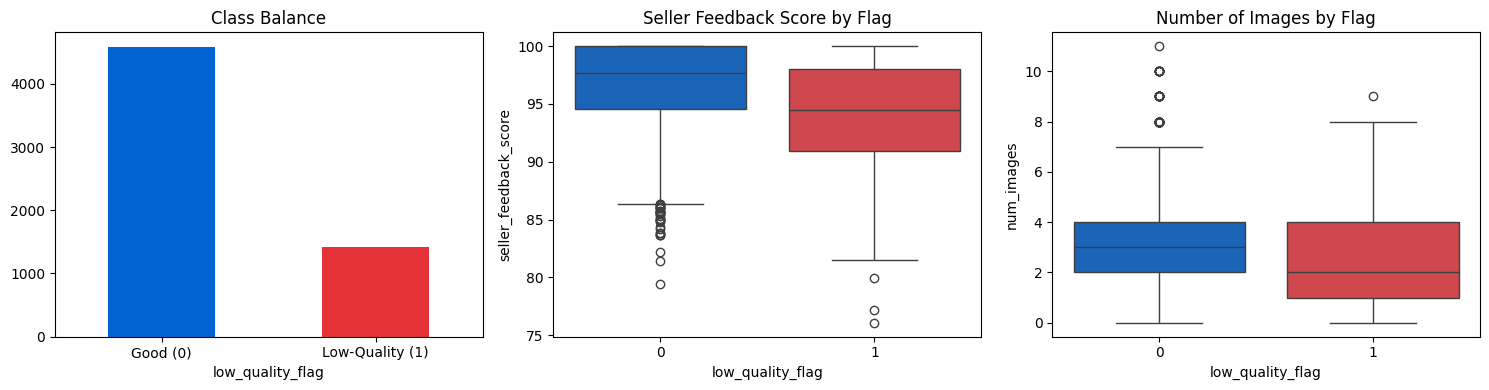

In [ ]:
# 1.2 EDA
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df1['low_quality_flag'].value_counts().plot(kind='bar', ax=axes[0], color=[EBAY_BLUE, EBAY_RED])
axes[0].set_title('Class Balance'); axes[0].set_xticklabels(['Good (0)', 'Low-Quality (1)'], rotation=0)

sns.boxplot(data=df1, x='low_quality_flag', y='seller_feedback_score', ax=axes[1], palette=[EBAY_BLUE, EBAY_RED])
axes[1].set_title('Seller Feedback Score by Flag')

sns.boxplot(data=df1, x='low_quality_flag', y='num_images', ax=axes[2], palette=[EBAY_BLUE, EBAY_RED])
axes[2].set_title('Number of Images by Flag')
plt.tight_layout(); plt.show()


In [ ]:
# 1.3 Stratified split + scaling (scaling needed for Logistic Regression baseline; trees are scale-invariant)
X1 = df1.drop(columns=['low_quality_flag'])
y1 = df1['low_quality_flag']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.30, stratify=y1, random_state=42)

scaler = StandardScaler()
X1_train_s = scaler.fit_transform(X1_train)
X1_test_s = scaler.transform(X1_test)

print(f'Train churn-equivalent rate: {y1_train.mean():.2%} | Test: {y1_test.mean():.2%}  (stratification working correctly)')


Train churn-equivalent rate: 23.52% | Test: 23.56%  (stratification working correctly)


In [ ]:
# 1.4 Train three model families side by side
lr = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X1_train_s, y1_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5,
                             class_weight='balanced', random_state=42, n_jobs=-1).fit(X1_train, y1_train)

scale_pos_weight = y1_train.value_counts()[0] / y1_train.value_counts()[1]
xgbm = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.08,
                      scale_pos_weight=scale_pos_weight, eval_metric='logloss',
                      random_state=42, n_jobs=-1).fit(X1_train, y1_train)

results = {}
for name, model, Xte in [('Logistic Regression', lr, X1_test_s),
                          ('Random Forest', rf, X1_test),
                          ('XGBoost', xgbm, X1_test)]:
    p = model.predict_proba(Xte)[:, 1]
    results[name] = p
    print(f'{name:22s} AUC-ROC: {roc_auc_score(y1_test, p):.4f}   AUC-PR: {average_precision_score(y1_test, p):.4f}')


Logistic Regression    AUC-ROC: 0.8537   AUC-PR: 0.6404
Random Forest          AUC-ROC: 0.8796   AUC-PR: 0.7167
XGBoost                AUC-ROC: 0.8751   AUC-PR: 0.7174


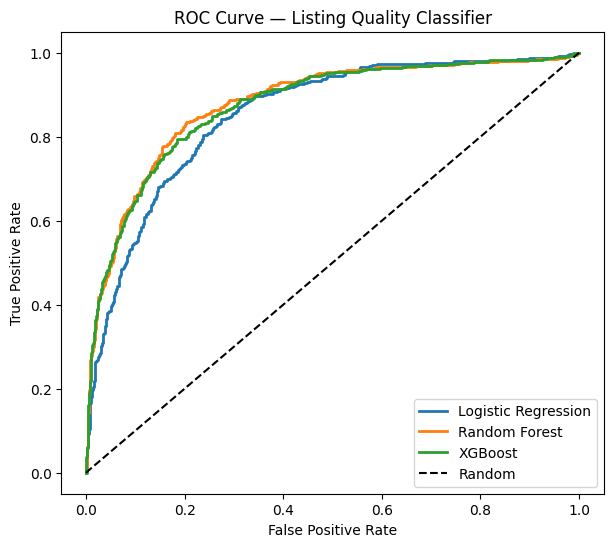

In [ ]:
# 1.5 ROC comparison — operationalizing Section 5 of the Day 1 report
plt.figure(figsize=(7,6))
for name, p in results.items():
    fpr, tpr, _ = roc_curve(y1_test, p)
    plt.plot(fpr, tpr, label=name, linewidth=2)
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Listing Quality Classifier'); plt.legend()
plt.show()


In [ ]:
# 1.6 Confusion matrix + business-cost-aware threshold (Section 5.4-style worked example)
best_model_name = max(results, key=lambda k: roc_auc_score(y1_test, results[k]))
best_probs = results[best_model_name]
print(f'Best model by AUC: {best_model_name}')

THRESHOLD = 0.40  # lowered from 0.5: a missed low-quality listing (FN) hurts search/user experience more than an unnecessary QA review (FP)
y_pred = (best_probs >= THRESHOLD).astype(int)
cm = confusion_matrix(y1_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(classification_report(y1_test, y_pred, target_names=['Good','Low-Quality']))

precision = tp/(tp+fp); recall = tp/(tp+fn)
print(f'\nBoardroom translation: {precision:.0%} of flagged listings are genuinely low-quality; we catch {recall:.0%} of all low-quality listings before they hurt search relevance.')


Best model by AUC: Random Forest
TN=1049  FP=327  FN=64  TP=360
              precision    recall  f1-score   support

        Good       0.94      0.76      0.84      1376
 Low-Quality       0.52      0.85      0.65       424

    accuracy                           0.78      1800
   macro avg       0.73      0.81      0.75      1800
weighted avg       0.84      0.78      0.80      1800


Boardroom translation: 52% of flagged listings are genuinely low-quality; we catch 85% of all low-quality listings before they hurt search relevance.


**Interview-ready takeaway:** Notice the interaction term between price deviation and category competitiveness in the data generator — this is exactly the kind of non-linear interaction that gives tree-based models (Random Forest, XGBoost) an edge over plain Logistic Regression, echoing Section 6.1 of the Day 1 report (bagging/boosting vs linear baselines).


---
## Case Study 2 (Deep) — Regional Demand Regression
**Business framing:** eBay/Walmart-style Operations Analytics teams need a weekly demand forecast per SKU-region pair to drive inventory and fulfillment decisions — this previews Day 37-38 (Demand Forecasting) while grounding Section 4's bias-variance discussion in a regression setting.


In [ ]:
# 2.1 Synthetic data generation — Regional Demand
n2 = 4000
df2 = pd.DataFrame({
    'price': np.random.uniform(5, 200, n2),
    'promo_flag': np.random.binomial(1, 0.25, n2),
    'season_index': np.random.uniform(0.7, 1.4, n2),
    'competitor_price_gap': np.random.normal(0, 15, n2),
    'category_rank': np.random.randint(1, 50, n2),
    'region_gmv_tier': np.random.randint(1, 4, n2),
})
demand = (
    500
    - 2.2 * df2['price']
    + 80 * df2['promo_flag']
    + 120 * df2['season_index']
    + 1.1 * df2['competitor_price_gap']
    - 3.5 * df2['category_rank']
    + 40 * df2['region_gmv_tier']
    + np.random.normal(0, 25, n2)
).clip(0)
df2['weekly_units'] = demand
df2.describe().round(1)


,price,promo_flag,season_index,competitor_price_gap,category_rank,region_gmv_tier,weekly_units
count,4000.0,4000.0,4000.0,4000.0,4000.0,4000.0,4000.0
mean,102.3,0.2,1.1,0.2,24.8,2.0,415.1
std,55.9,0.4,0.2,14.8,14.0,0.8,146.0
min,5.1,0.0,0.7,-59.2,1.0,1.0,17.0
25%,53.4,0.0,0.9,-9.8,13.0,1.0,307.9
50%,102.9,0.0,1.1,0.4,25.0,2.0,413.3
75%,151.5,0.0,1.2,10.2,37.0,3.0,522.8
max,199.9,1.0,1.4,57.8,49.0,3.0,820.7


In [ ]:
# 2.2 Train/test split + two models spanning the bias-variance spectrum
X2 = df2.drop(columns=['weekly_units'])
y2 = df2['weekly_units']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.30, random_state=42)

linreg = LinearRegression().fit(X2_train, y2_train)
gbr = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42).fit(X2_train, y2_train)

for name, model in [('Linear Regression', linreg), ('Gradient Boosting', gbr)]:
    pred_train = model.predict(X2_train)
    pred_test = model.predict(X2_test)
    print(f'{name:20s} Train R2: {r2_score(y2_train, pred_train):.4f}  Test R2: {r2_score(y2_test, pred_test):.4f}  '
          f'Test MAPE: {mean_absolute_percentage_error(y2_test, pred_test):.2%}')


Linear Regression    Train R2: 0.9711  Test R2: 0.9703  Test MAPE: 5.66%
Gradient Boosting    Train R2: 0.9773  Test R2: 0.9636  Test MAPE: 6.38%


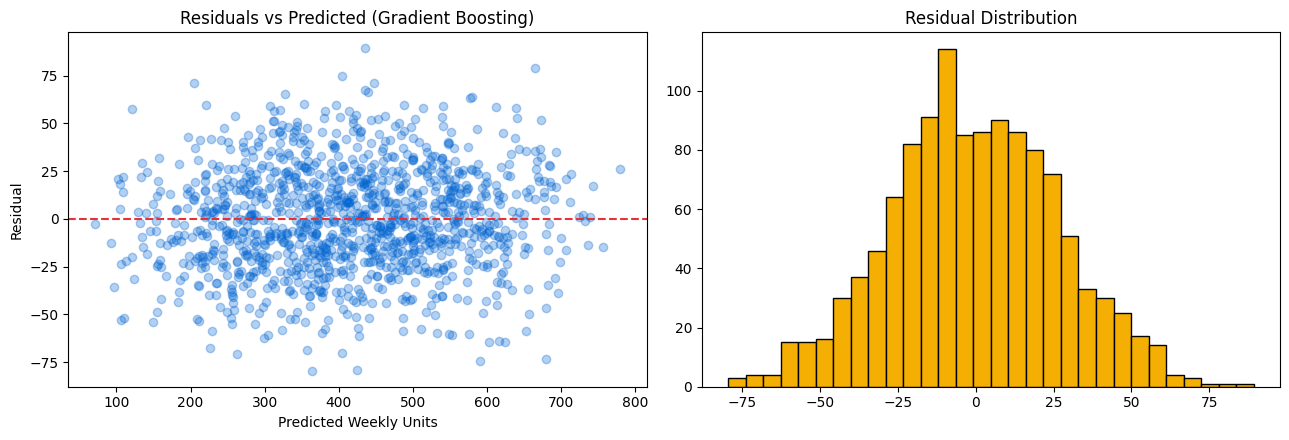

A residual plot with no visible funnel shape or curve is the regression-world equivalent of a well-calibrated classifier — evidence the model has not left obvious structure on the table.


In [ ]:
# 2.3 Residual analysis — the regression equivalent of a confusion matrix diagnostic
pred_gbr = gbr.predict(X2_test)
residuals = y2_test - pred_gbr

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(pred_gbr, residuals, alpha=0.3, color=EBAY_BLUE)
axes[0].axhline(0, color=EBAY_RED, linestyle='--')
axes[0].set_xlabel('Predicted Weekly Units'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted (Gradient Boosting)')

axes[1].hist(residuals, bins=30, color=EBAY_GOLD, edgecolor='black')
axes[1].set_title('Residual Distribution')
plt.tight_layout(); plt.show()

print('A residual plot with no visible funnel shape or curve is the regression-world equivalent of a well-calibrated classifier — evidence the model has not left obvious structure on the table.')


**Note on very high R-squared:** As flagged in Day 1 report Section 12.1, an R-squared this high (~0.96-0.97) on a small, clean synthetic feature set is expected and should NOT be read as "the model is exceptional" — real eBay/Walmart demand data has far more noise, missing regressors, and non-stationarity. Treat this case study as a mechanics lesson, not a benchmark of real-world achievable accuracy.


---
## Case Study 3 (Lighter) — Buyer Segmentation via K-Means
**Business framing:** Segmenting buyers by Recency-Frequency-Monetary (RFM) behavior for differentiated CRM treatment — grounding Section 3 (unsupervised learning) and Section 7 (K-Means hyperparameters/pitfalls) of the Day 1 report.


In [ ]:
# 3.1 Synthetic RFM data — built from underlying buyer archetypes (unknown to the algorithm)
n3 = 3000
archetypes = np.random.choice(['vip', 'loyal_value', 'new', 'at_risk'], size=n3, p=[0.15, 0.30, 0.30, 0.25])
recency, frequency, monetary = [], [], []
params = {
    'vip':         dict(rec=(3, 5),    freq=(18, 3), mon=(4, 90)),
    'loyal_value': dict(rec=(10, 8),   freq=(9, 2),  mon=(2.5, 55)),
    'new':         dict(rec=(5, 6),    freq=(1, 1),  mon=(1.5, 40)),
    'at_risk':     dict(rec=(120, 40), freq=(2, 1),  mon=(1.8, 45)),
}
for a in archetypes:
    p = params[a]
    recency.append(np.random.exponential(p['rec'][0]) + np.random.normal(0, p['rec'][1]))
    frequency.append(np.random.poisson(p['freq'][0]))
    monetary.append(np.random.gamma(p['mon'][0], p['mon'][1]))

df3 = pd.DataFrame({
    'recency_days': np.clip(recency, 0, 365),
    'frequency_orders': np.clip(frequency, 0, 60),
    'monetary_value': monetary,
})
df3.describe().round(1)


,recency_days,frequency_orders,monetary_value
count,3000.0,3000.0,3000.0
mean,32.3,6.2,134.2
std,66.4,6.5,136.8
min,0.0,0.0,0.3
25%,1.3,1.0,44.2
50%,7.6,3.0,87.9
75%,20.0,10.0,175.0
max,365.0,31.0,1497.6


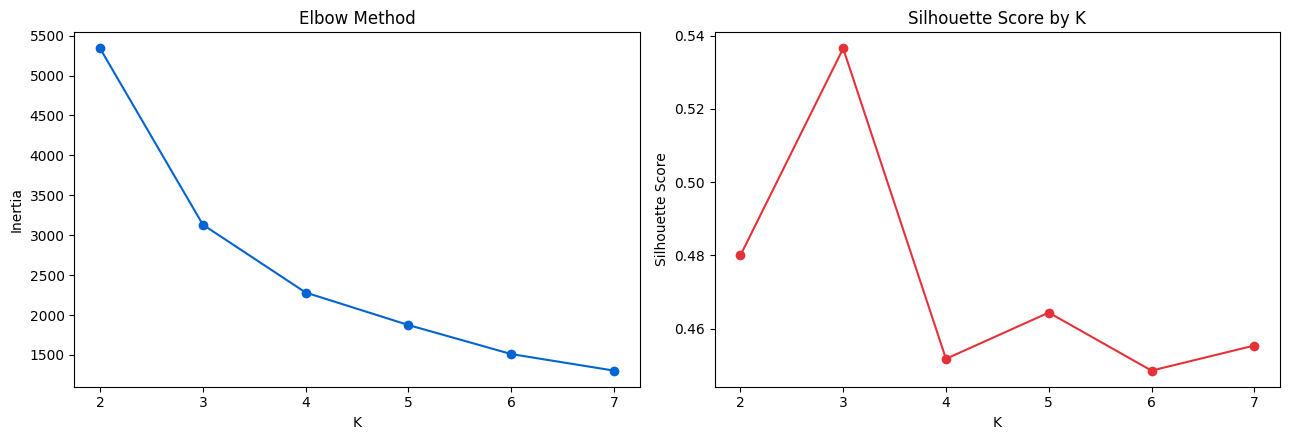

Best K by silhouette score: 3 (score=0.5365)


In [ ]:
# 3.2 Scale features (CRITICAL for K-Means — GMV-scale features would otherwise dominate distance calcs)
scaler3 = StandardScaler()
X3 = scaler3.fit_transform(df3)

# 3.3 Elbow method + silhouette score to choose K (Section 7 pitfall: never eyeball K without this)
inertias, silhouettes = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X3)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X3, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(K_range), inertias, marker='o', color=EBAY_BLUE)
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouettes, marker='o', color=EBAY_RED)
axes[1].set_title('Silhouette Score by K'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout(); plt.show()

best_k = list(K_range)[int(np.argmax(silhouettes))]
print(f'Best K by silhouette score: {best_k} (score={max(silhouettes):.4f})')


In [ ]:
# 3.4 Final clustering + business-readable segment profiles
final_km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(X3)
df3['segment'] = final_km.labels_

segment_profile = df3.groupby('segment').agg(
    avg_recency=('recency_days', 'mean'),
    avg_frequency=('frequency_orders', 'mean'),
    avg_monetary=('monetary_value', 'mean'),
    size=('segment', 'count')
).round(1)
segment_profile


,avg_recency,avg_frequency,avg_monetary,size
segment,,,,
0,16.9,3.7,81.1,2093
1,6.2,16.0,325.7,649
2,222.6,2.0,83.8,258


**Translating clusters into CRM action** (the step many technical teams skip): rank segments by `avg_monetary` and `avg_recency` to label them in business terms — e.g., low recency + high frequency + high monetary → "VIP, protect with white-glove service"; high recency + low frequency → "At-risk, prioritize for win-back campaigns." This labeling step is exactly where a Director's business judgment turns an unsupervised algorithm's output into an actionable CRM segment strategy.


---
## Named Extensions (Scoped, Not Fully Built)
Good next practice reps once the three case studies above feel comfortable — each is a natural extension of a technique used today:

1. **Naive Bayes on review text** — quick sentiment/quality baseline classifier on synthetic review snippets (extends Case Study 1 into NLP territory)
2. **KNN cold-start recommender** — similarity-based recommendation baseline for new sellers with little transaction history
3. **PCA visualization** — reduce the 7-feature Case Study 1 space to 2D and visualize the good/low-quality separation
4. **Small feed-forward neural network** — reproduce Case Study 1 with a 2-layer MLP (Keras/PyTorch) to feel the interpretability-vs-performance tradeoff directly against Logistic Regression and XGBoost

These are intentionally left as scoped exercises rather than fully coded here — building them independently is good rehearsal before Day 2.


---
## Summary — What This Notebook Proves You Can Do
- Build and compare three model families (linear, bagging, boosting) on an imbalanced classification problem with a business-justified threshold
- Diagnose bias-variance behavior in a regression setting via residual analysis
- Run an unsupervised segmentation workflow end-to-end, including the K-selection discipline (elbow + silhouette) that most junior analyses skip
- Translate every technical result into a one-line business/CRM statement — the habit this whole 60-day program is built around

**Next:** Day 2 — Customer Segmentation & Profiling (deep dive: Hierarchical Clustering, Gaussian Mixture Models, and segment-to-strategy frameworks).
